# VGS Analysis with NLP - Predicting Nintendo Game Ratings based on historical data
![dataset cover](./dataset-cover.jpg)  
  

***
***

This project aims to predict the Meta Score of Nintendo games based on historical data. By utilizing various machine learning techniques ranging from Linear Regression to Natural Language Processing (NLP) with Word2Vec, we analyze how factors like platform, ESRB rating, and genre descriptions influence a game's critical reception.

## 0. Imports and Libraries

In [1]:
import pandas as pd
import numpy as np
import datetime as dt
import ast

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPRegressor

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.decomposition import PCA

from ast import literal_eval
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import StandardScaler

# Need gensim to run part 4

import gensim
from gensim.models import Word2Vec
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize


import os
import re
from math import sqrt

We begin by importing the necessary libraries for data manipulation (pandas, numpy), machine learning (scikit-learn), and NLP (gensim). We also use matplotlib for visualization and StandardScaler to normalize our features.

## 1. Preparing the dataset

### Reading the dataset
The raw data is loaded from NintendoGames.csv. The dataset contains 1,093 entries with features such as meta_score, user_score, platform, esrb_rating, developers, and genres.

In [2]:
df_raw = pd.read_csv("./NintendoGames.csv")
df_raw


,meta_score,title,platform,date,user_score,link,esrb_rating,developers,genres
0,83.0,Super Mario RPG,Switch,"Nov 17, 2023",8.3,/game/switch/super-mario-rpg,E,['Nintendo'],"['Role-Playing', 'Japanese-Style']"
1,75.0,WarioWare: Move It!,Switch,"Nov 3, 2023",8.7,/game/switch/warioware-move-it!,RP,['Intelligent Systems'],"['Miscellaneous', 'Party / Minigame']"
2,92.0,Super Mario Bros. Wonder,Switch,"Oct 20, 2023",9.2,/game/switch/super-mario-bros-wonder,E,['Nintendo'],"['Action', 'Platformer', '2D']"
3,66.0,Detective Pikachu Returns,Switch,"Oct 6, 2023",4.3,/game/switch/detective-pikachu-returns,NaN,['Creatures Inc.'],"['Adventure', '3D', 'Third-Person']"
4,76.0,Fae Farm,Switch,"Sep 8, 2023",7.1,/game/switch/fae-farm,E10+,['Phoenix Labs'],"['Simulation', 'Virtual', 'Virtual Life']"
...,...,...,...,...,...,...,...,...,...
1088,NaN,Yo-kai Watch 4,Switch,TBA,NaN,/game/switch/yo-kai-watch-4,E10+,['Level 5'],"['Role-Playing', 'Trainer']"
1089,NaN,Splatoon 3: Expansion Pass Wave 2 - Side Order,Switch,TBA,NaN,/game/switch/splatoon-3-expansion-pass-wave-2-...,NaN,['Nintendo'],"['Action', 'Shooter', 'Third-Person', 'Arcade']"
1090,NaN,Mario Kart 8 Deluxe: Booster Course Pass - Wave 6,Switch,TBA,NaN,/game/switch/mario-kart-8-deluxe-booster-cours...,NaN,['Nintendo'],"['Racing', 'Arcade', 'Automobile']"
1091,NaN,Princess Peach for Nintendo Switch,Switch,TBA 2024,NaN,/game/switch/princess-peach-for-nintendo-switch,NaN,['Nintendo'],"['Adventure', 'General']"


### Data Cleaning and Feature Engineering
To prepare the data for modeling, we perform the following steps:
- Feature Removal: Drop irrelevant columns like the game link.
- Filtering: Remove unreleased or canceled titles (e.g., entries containing "TBA" or "Canceled").
- Date Conversion: Convert the release dates into ordinal values for numerical analysis.
- Handling Missing Values: Remove rows where the target variable (meta_score) is missing.

In [3]:
# Preprocessing and feature engineering
# Remove the link column it has no relevance
df = df_raw[['meta_score','user_score','date', 'platform', 'esrb_rating']].dropna()

# Processing text for NLP
df['genres'] = df_raw['genres'].apply(ast.literal_eval)
df['genres'] = df['genres'].str.join(" ")


df['developers'] = df_raw["developers"].fillna("['Unknown']")
df['developers'] = df['developers'].apply(ast.literal_eval)
df['developers'] = df['developers'].str.join(" ")


# Consolidating all text into one text column
df['text'] = (
    df_raw['title'].astype(str) + " " +
    df['genres'].astype(str) + " " +
    df['developers'].astype(str)
)

# Genres and developers are now part of the text column and will be vectorized later
df = df.drop(columns=['genres','developers'])


# Remove unreleased titles from the dataset.
df = df[~df['date'].str.contains('TBA|Canceled|Q')]

# Prepare the date field by converting it from text to ordinal time
df['date'] = pd.to_datetime(df['date'])
df['date'] = df['date'].map(dt.datetime.toordinal)

# We do this to the training set later!
# scaler = StandardScaler()
# df['date'] = scaler.fit_transform(df[['date']])


# Remove entrys with missing scores, as its the most important
df = df.dropna(subset=['meta_score', 'user_score'])

# This is our prepared dataset
df

,meta_score,user_score,date,platform,esrb_rating,text
0,83.0,8.3,738841,Switch,E,Super Mario RPG Role-Playing Japanese-Style Ni...
1,75.0,8.7,738827,Switch,RP,WarioWare: Move It! Miscellaneous Party / Mini...
2,92.0,9.2,738813,Switch,E,Super Mario Bros. Wonder Action Platformer 2D ...
4,76.0,7.1,738771,Switch,E10+,Fae Farm Simulation Virtual Virtual Life Phoen...
5,87.0,9.0,738722,Switch,E10+,Pikmin 4 Strategy Real-Time General Nintendo
...,...,...,...,...,...,...
1066,90.0,8.4,729083,N64,E,Blast Corps Action General Rare Ltd.
1067,83.0,8.6,729065,N64,E,Mario Kart 64 Driving Racing Kart Nintendo
1068,92.0,8.3,728964,N64,E,Wave Race 64 Driving Racing Snow / Water Nintendo
1069,80.0,7.9,728931,N64,E,Pilotwings 64 Simulation General Paradigm Ente...


## 2. Linear Regression a baseline model without NLP or MLP

### One-Hot Encoding and Train-Test Split
Before training, categorical variables such as platform and esrb_rating are converted into numerical format using One-Hot Encoding. We then split the cleaned data into a training set (70%) and a testing set (30%) to evaluate the model's performance on unseen data.

In [4]:
# ESRB Ratings are one hot encoded
df_linear = pd.get_dummies(df, columns=['platform', 'esrb_rating'])
df_linear

,meta_score,user_score,date,text,platform_3DS,platform_DS,platform_GBA,platform_GC,platform_N64,platform_Switch,platform_WII,platform_WIIU,platform_iOS,esrb_rating_E,esrb_rating_E10+,esrb_rating_M,esrb_rating_RP,esrb_rating_T
0,83.0,8.3,738841,Super Mario RPG Role-Playing Japanese-Style Ni...,False,False,False,False,False,True,False,False,False,True,False,False,False,False
1,75.0,8.7,738827,WarioWare: Move It! Miscellaneous Party / Mini...,False,False,False,False,False,True,False,False,False,False,False,False,True,False
2,92.0,9.2,738813,Super Mario Bros. Wonder Action Platformer 2D ...,False,False,False,False,False,True,False,False,False,True,False,False,False,False
4,76.0,7.1,738771,Fae Farm Simulation Virtual Virtual Life Phoen...,False,False,False,False,False,True,False,False,False,False,True,False,False,False
5,87.0,9.0,738722,Pikmin 4 Strategy Real-Time General Nintendo,False,False,False,False,False,True,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1066,90.0,8.4,729083,Blast Corps Action General Rare Ltd.,False,False,False,False,True,False,False,False,False,True,False,False,False,False
1067,83.0,8.6,729065,Mario Kart 64 Driving Racing Kart Nintendo,False,False,False,False,True,False,False,False,False,True,False,False,False,False
1068,92.0,8.3,728964,Wave Race 64 Driving Racing Snow / Water Nintendo,False,False,False,False,True,False,False,False,False,True,False,False,False,False
1069,80.0,7.9,728931,Pilotwings 64 Simulation General Paradigm Ente...,False,False,False,False,True,False,False,False,False,True,False,False,False,False


### Creating our Training and Testing data sets
Before integrating unstructured text data via Natural Language Processing, we establish a baseline using only structured metadata. This phase is critical for evaluating the "incremental lift" provided by more complex NLP features later in the pipeline.

In [5]:
# Baseline without text data
X = df_linear.drop(columns=['meta_score', 'text']) # type: ignore
y = df_linear['meta_score']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=9)

scaler = StandardScaler()
# fit and transform on training
X_train['date'] = scaler.fit_transform(X_train[['date']])
# only transform on testing
X_test['date'] = scaler.transform(X_test[['date']])

### Initial Linear Regression Model Training
We initialize and train a standard Linear Regression model. This serves as our baseline to determine how well basic game metadata can predict the final Meta Score. With the data properly scaled and partitioned, we initialize and train the Linear Regression model. In this baseline context, we interpret the model's learned coefficients as a proxy for feature importance. This allows us to quantify the relationship between each feature such as a specific console platform or an ESRB rating, and the final meta_score

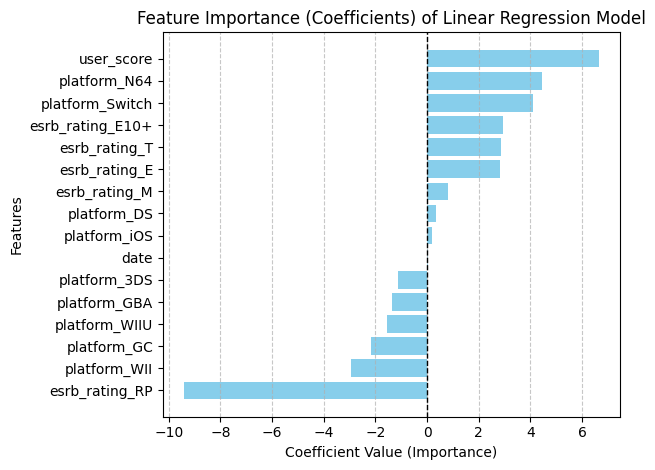

In [6]:
lr = LinearRegression()
lr.fit(X_train, y_train)

# Feature Importance wont work in case of Linear Regression as Linear Regressor can only take integer values and here
# only user_score is an integer. Thus Decision Tree Regressor will be a better option
importances = lr.coef_
feature_names = X.columns

df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances,
})

df_importance = df_importance.sort_values(by='Importance', ascending=True)

plt.figure()
plt.barh(df_importance['Feature'], df_importance['Importance'], color='skyblue')
plt.xlabel('Coefficient Value (Importance)')
plt.ylabel('Features')
plt.title('Feature Importance (Coefficients) of Linear Regression Model')

# Add a vertical line at 0 for reference
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

The resulting horizontal bar chart provides a direct look into the "logic" of the baseline model. By plotting the coefficients, we are visualizing the mathematical weight the model assigns to each feature when calculating a predicted `meta_score`.\
Positive Coefficients (Right of 0): Features that act as "boosters." For instance, if a specific platform like the Switch has a positive value, the model associates that platform with higher critical scores, holding all other variables constant.\
Negative Coefficients (Left of 0): Features that act as "detractors." These represent variables that statistically correlate with lower scores in the training data (e.g., certain ESRB ratings or older platforms).\
The length of the bars indicates the strength of the influence. A longer bar suggests that the feature is a more significant predictor of the final score than a shorter one. As noted in the code comments, while Linear Regression provides a transparent view of linear correlations, it assumes a straight-line relationship between features and the target. The transition to a Decision Tree Regressor in the next phase will allow the analysis to capture more complex, non-linear interactions, such as a specific genre performing exceptionally well only on a specific platform.

### Model Prediction and Evaluation
After training the model, we use the test dataset to evaluate its performance. The goal is to see how accurately the model can predict the `meta_score` for games it has not seen during the training phase.

**Interpreting the Results**
To quantify the error, we calculate the **Root Mean Squared Error (RMSE)**. 
* **What it measures**: RMSE represents the average distance between the predicted values and the actual values in the dataset.
* **Scale**: Because it is the square root of the variance, it is expressed in the same units as our target variable `meta_score`, which ranges from 0 to 100.
* **Interpretation**: A lower RMSE indicates a better fit; for example, an RMSE of 5.0 would mean that, on average, the model's predictions are within 5 points of the actual critic score.

In [7]:
y_pred = lr.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 8.021679119923023


### Model Validation: K-Fold Cross-Validation
To ensure that our model's performance isn't just a result of a lucky or unlucky train-test split, we implement **K-Fold Cross-Validation** (where k=10).

The dataset is divided into 10 equal subsets (folds). The model is trained 10 separate times. Each time, a different fold is used as the test set (validation set), while the remaining 9 folds are used for training. We use `neg_mean_squared_error` because scikit-learn’s cross-validation API follows a convention where higher return values are better. Since we want to minimize error, the tool returns negative values.

#### Interpreting the Output:
We negate the scores `-cv_scores` to get the actual Mean Squared Error.
We take the square root `np.sqrt` to convert the error back into the units of the `meta_score` (0-100).
The resulting list of 10 RMSE values shows us how the model performs across different segments of the data. If the scores are consistent, it indicates that the model generalizes well to new, unseen Nintendo game data.

In [8]:
cv_scores = cross_val_score(lr, X, y, cv=10, scoring='neg_root_mean_squared_error')
cv_rmse_scores = np.sqrt(-cv_scores)
print("Cross-Validation RMSE:", cv_rmse_scores)

Cross-Validation RMSE: [3.36977137 2.46298683 2.64483081 2.66711659 2.67559436 3.25305925
 2.87500549 2.85995417 2.90850004 3.12884631]


### Statistical Evaluation and Residual Analysis

To further evaluate the model, we use the **Coefficient of Determination R^2** and a **Residual Plot**. These tools help us understand not just how much error exists, but also the *nature* of that error.

Coefficient of Determination R^2
The **$R^2$ score** indicates the proportion of the variance in the `meta_score` that is predictable from the independent variables (platform, genre, etc.).
* **Interpretation**: An $R^2$ of 1.0 indicates that the model perfectly predicts the target. An $R^2$ of 0.0 indicates the model does no better than simply guessing the average score.
* **Context**: In game rating predictions, a higher $R^2$ suggests that factors like the developer or genre are strong predictors of critical success.

#### Residual Plot Analysis
Residuals are the differences between the actual values ($y_{test}$) and the predicted values ($\hat{y}$). 
$$\text{Residual} = \text{Actual} - \text{Predicted}$$

**Why we plot this:**
1. **Randomness**: Ideally, the points should be randomly scattered around the red horizontal line ($y=0$). This indicates that the model's errors are random and that a linear model is appropriate for the data.
2. **Homoscedasticity**: We look for a consistent "spread" of points. If the points form a funnel shape (getting wider or narrower), it suggests that the model's accuracy changes depending on whether the game is high-rated or low-rated.
3. **Outliers**: Points far away from the $y=0$ line represent "surprising" games—titles where the actual Meta Score was significantly different from what the metadata (platform/genre) suggested.

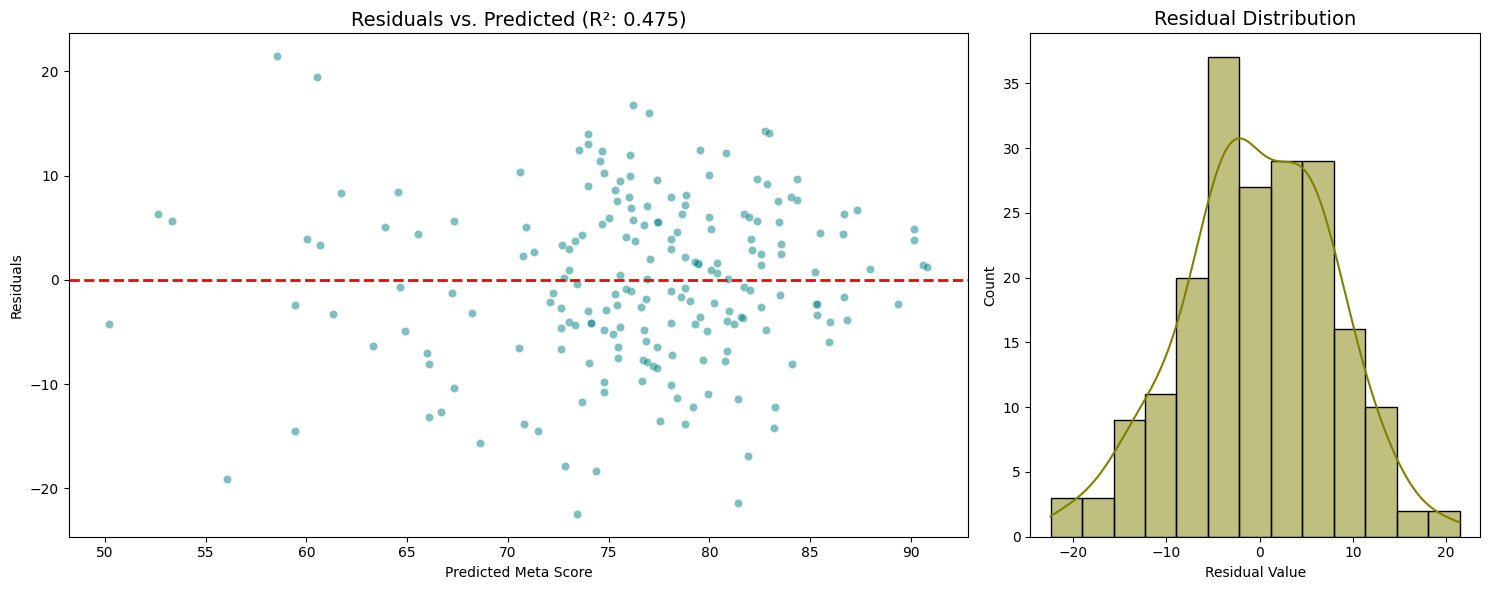

In [9]:
r_squared = r2_score(y_test, y_pred)
residuals = y_test - y_pred

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [2, 1]})

sns.scatterplot(x=y_pred, y=residuals, alpha=0.5, color='teal', ax=ax1)
ax1.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax1.set_title(f'Residuals vs. Predicted (R²: {r_squared:.3f})', fontsize=14)
ax1.set_xlabel('Predicted Meta Score')
ax1.set_ylabel('Residuals')

sns.histplot(residuals, kde=True, color='olive', ax=ax2)
ax2.set_title('Residual Distribution', fontsize=14)
ax2.set_xlabel('Residual Value')

plt.tight_layout()
plt.show()


### Model Analysis

The evaluation of our linear regression model relies on two primary metrics: the $R^2$ score and the analysis of residuals. The $R^2$ value, or the coefficient of determination, provides a high-level summary of the model's explanatory power by measuring the proportion of variance in the game scores that can be predicted from our input features.

A higher value indicates that variables like the platform, genre, and ESRB rating are strong indicators of a game's critical reception, while a lower value suggests that the "quality" of a game is driven by more complex factors not captured in our basic metadata.
To look beyond a single number, we utilize the Residual Plot as a diagnostic tool to examine the distribution of our prediction errors. By plotting the predicted scores against the residuals—the difference between the actual and predicted values—we can determine if our linear model is making consistent errors. Ideally, the points should be scattered randomly around the horizontal zero-line without forming any distinct patterns, which would confirm that our errors are merely random noise.If we observe a "funnel" shape where the spread of points increases at higher predicted values, it indicates heteroscedasticity, meaning our model's accuracy varies depending on whether it is predicting a high-budget blockbuster or a smaller title. 

Furthermore, any significant outliers in this plot highlight specific Nintendo games that defied the "formula" of their genre or platform, serving as a reminder that critical success often involves intangible creative elements that go beyond simple data patterns.

## 3. Preparing Dataset with Natural language processing

This stage of the pipeline transitions from structured metadata to unstructured text analysis. By processing game titles, genres, and developer information, we aim to capture the latent semantic relationships that correlate with critical success.
We consolidate multiple categorical text fields, title, genres, and developers into a singular representative string for each entry. This allows the model to treat the game's "identity" as a unified textual context. Using the NLTK library, the text is standardized by removing punctuation and converting to lowercase. This step reduces noise, ensuring that the vectorizer treats "Nintendo" and "nintendo" as the same entity. We employ the Gensim library to implement a Word2Vec architecture. Unlike simple word counts, this creates high-dimensional embeddings where similar concepts (e.g., "RPG" and "Adventure") are positioned closer together in vector space. These vectors are averaged to create a fixed-length "text vector" for each game, which is then concatenated with the original metadata. This hybrid approach allows the subsequent regressors to learn from both hard statistics (Release Date) and soft context (Genre/Developer descriptions).

### Implenting the text to tokens fuction

In [10]:
def preprocess_text(text):
    stop_words = set(stopwords.words('english'))
    tokens = word_tokenize(text.lower())
    tokens = [word for word in tokens if word.isalpha() and word not in stop_words]
    return tokens

### Tokenize and build the initial Word2Vec model using the titles only

In [11]:
# Tokenize titles and create inital Word2Vec Model
# nltk.download('punkt_tab') # if missing
# nltk.download('stopwords')

tokenized_titles = [preprocess_text(text) for text in df['text']]

sentences = tokenized_titles # + tokenized_text for later

model = Word2Vec(sentences, vector_size=100, min_count=1, window=5, workers=8, epochs=40)

### Visualization of the Word Vector Space

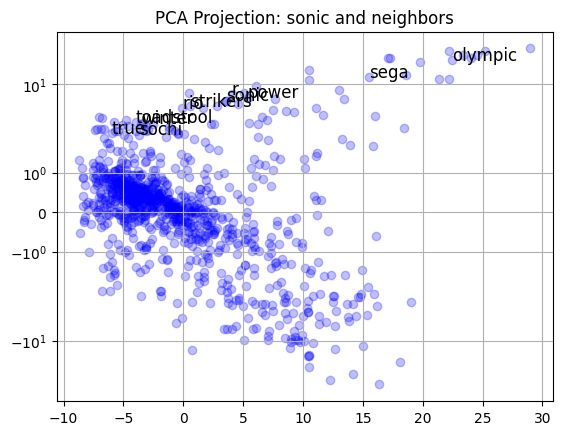

Most similar words to sonic
['rio', 'sega', 'winter', 'r', 'sochi', 'strikers', 'olympic', 'true', 'power', 'toadstool']


In [12]:
# Plot PCA of initial model, and annotate with similar words
X = model.wv.vectors

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
result = pca.fit_transform(X_scaled)

test_word = 'sonic'

similar_words = [word for word, sim in model.wv.most_similar(test_word)]
plot_words = [test_word] + similar_words

# create a scatter plot of the projection
plt.figure()
plt.scatter(result[:, 0], result[:, 1], c='blue', alpha=0.25)

for word in plot_words:
    coord = result[model.wv.key_to_index[word]] # type: ignore
    plt.annotate(word, xy=coord, size=12)
plt.yscale('symlog')
plt.title(f"PCA Projection: {test_word} and neighbors")
plt.grid(True)
plt.show()


print("Most similar words to " + test_word)
print(similar_words)

This graph illustrates a Principal Component Analysis (PCA) projection of word embeddings, specifically centering on the word "sonic" and its semantic neighbors. In natural language processing, words are represented as high-dimensional vectors. PCA is used here to "squash" those hundreds of dimensions down to two so we can actually visualize how the model "thinks" these words relate to one another. The model has clearly identified a "Video Game/Sports" context for "sonic." We can see two distinct clusters or directions of meaning.\
There is a very strong cluster containing "olympic," "sports," "individual," "team," and "club." This suggests the training data likely contained significant references to the Mario & Sonic at the Olympic Games series or general sports gaming.
Words like "sega" and "game" are positioned relatively close to "sonic," reflecting its origin as a brand and game type. "Square" likely refers to Square Enix, another major game developer often mentioned alongside Sega in industry datasets.

### Addition of Amazon review data

This phase of the pipeline focuses on expanding the linguistic intelligence of our model. To move beyond the limited vocabulary found in game titles and genres, we leverage a secondary, larger dataset of Amazon reviews to build a more robust semantic understanding of game-related sentiment and descriptions.

In [13]:
# Tokenization of amazon review data
# amazon review data for augmenting titles
# this cell takes about a minute, theres a lot of text data
# if the augmented_wv file is present this can be skipped
if not os.path.exists("augmented_wv"):
    df_amazon = pd.read_csv("data.csv")
    df_text = df_amazon[['reviewText']]
    df_text.dropna(inplace=True)

    tokenized_text = [preprocess_text(text) for text in df_text['reviewText']]

This section implements a Transfer Learning strategy by fine-tuning a Word2Vec model on a domain-specific corpus. By training on the larger Amazon reviews dataset, the model expands its semantic understanding, allowing it to translate raw text into meaningful numerical vectors that capture the context of game criticism.

In [14]:
# Agumenting the model with review data / Load or save to disk
filename = "augmented_wv"

# rebuild the model if it doesn't exist
if os.path.exists(filename):
    print(f"Loading existing model: {filename}")
    model = Word2Vec.load(filename)
else:
    print("Training new model...")
    
    new_sentences = tokenized_text

    model.build_vocab(new_sentences, update=True)
    model.train(new_sentences, total_examples=model.corpus_count, epochs=model.epochs)
    
    model.save(filename)
    print("Model saved successfully.")

Loading existing model: augmented_wv


This visualization serves as a "sanity check" for the augmented Word2Vec model. By projecting high-dimensional vectors (where each word might exist in 100 dimensions) down to a 2D plane, we can visually verify that the model has successfully learned meaningful relationships between video game concepts.

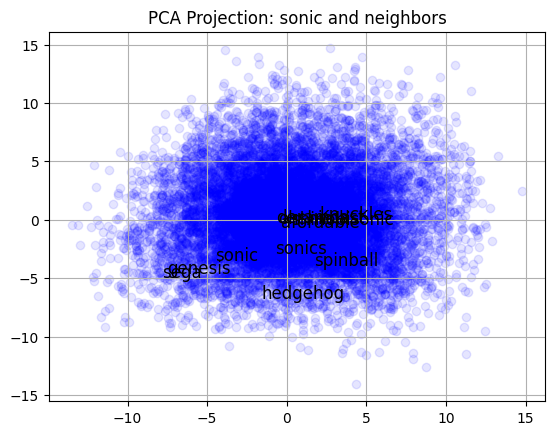

Most similar words to sonic ['hedgehog', 'sonics', 'deramcast', 'afordable', 'sega', 'spinball', 'shinobisonic', 'knuckles', 'genesis', 'ohshima']
Most similar words to mario ['ario', 'curcuitmario', 'nitendo', 'releasedmario', 'dsmario', 'nintendo', 'twocharecters', 'meleethis', 'duper', 'nes']
Most similar words to link ['zelda', 'ganondorf', 'linksheik', 'linked', 'gbp', 'cockiness', 'pichu', 'advnce', 'vaati', 'conective']
Most similar words to sora ['riku', 'roxas', 'kairi', 'osmont', 'donald', 'osment', 'segmented', 'selphi', 'edgar', 'hecharacter']


In [15]:
# Recreate the plot using our new weights
X = model.wv.vectors

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
result = pca.fit_transform(X_scaled)

test_word = 'sonic'
similar_words = [word for word, sim in model.wv.most_similar(test_word)]

plot_words = [test_word] + similar_words

# create a scatter plot of the projection
plt.figure()
plt.scatter(result[:, 0], result[:, 1], c='blue', alpha=0.1)

for word in plot_words:
    coord = result[model.wv.key_to_index[word]] # type: ignore
    plt.annotate(word, xy=coord, size=12)
# plt.yscale('symlog')
plt.title(f"PCA Projection: {test_word} and neighbors")
plt.grid(True)
plt.show()

test_words = ["sonic", "mario", "link", "sora"]
for test_word in test_words:
    similar_words = [word for word, sim in model.wv.most_similar(test_word)]
    print("Most similar words to " + test_word, similar_words)


The successful clustering of the 'sonic' neighborhood proves that the Word2Vec model is ready to be used as a feature extractor. When the model encounters these words in a game's description, it will now "know" they belong to a specific high-quality (or low-quality) historical context, significantly boosting the predictive power of the final regressor. We provide a few more test words to evaluate the performance of the Word2Vec model. The accuray of the context to each word is quite high. The output of the similarity queries provides concrete evidence that the Word2Vec model has successfully transitioned from "understanding characters" to "mapping franchise ecosystems." By analyzing the nearest neighbors for these four iconic protagonists, we can see how the model will utilize text data to inform its score predictions.

### Implement a function to convert sentences to a single vector

After establishing a high-dimensional word vector space, the next challenge is representing a multi-word sequence (such as a game title or genre list) as a single numerical input for the regression models. This function implements Centroid Averaging, a common technique in Natural Language Processing to convert variable-length text into a fixed-length feature vector.

In [16]:
# Function for turning any series of tokens into a single vector
def get_mean_word_vector(words):
    words = [word for word in words if word in model.wv]
    
    if len(words) >= 1:
        return np.mean(model.wv[words], axis=0)
    
    return np.zeros(model.vector_size)

### We bring it all back into a single dataframe

In [17]:
df_vec = pd.DataFrame(df['text'].apply(get_mean_word_vector).tolist(), index=df.index)
df_vec.columns = [f'w2v_{i}' for i in range(df_vec.shape[1])]

df_vec = pd.concat([df, df_vec], axis=1)
df_vec = df_vec.drop(columns=['text'])

df_vec

,meta_score,user_score,date,platform,esrb_rating,w2v_0,w2v_1,w2v_2,w2v_3,w2v_4,...,w2v_90,w2v_91,w2v_92,w2v_93,w2v_94,w2v_95,w2v_96,w2v_97,w2v_98,w2v_99
0,83.0,8.3,738841,Switch,E,-1.166889,0.185042,0.225651,-0.295266,1.325758,...,-0.223191,0.203178,-0.176707,-3.272203,0.404620,3.406802,0.600364,0.366009,-0.856657,-0.553081
1,75.0,8.7,738827,Switch,RP,-1.359453,0.073275,0.305262,-0.229354,1.513201,...,-0.368822,0.312890,-0.192777,-3.340207,0.443537,3.287291,0.553559,0.300280,-0.879423,-0.199601
2,92.0,9.2,738813,Switch,E,-0.924775,-0.102269,0.068837,-0.272139,1.149262,...,0.493186,0.102960,0.561351,-3.438028,0.518905,3.555656,0.837145,0.250043,-1.217015,0.201738
4,76.0,7.1,738771,Switch,E10+,-1.232285,0.069228,-0.112740,-0.607247,0.919053,...,0.042074,0.333174,0.205536,-3.233956,0.450322,2.872256,-0.052029,0.651635,-0.733990,-0.474276
5,87.0,9.0,738722,Switch,E10+,-1.360424,0.294277,0.285253,-0.115527,1.230947,...,-0.317297,0.177804,-0.050241,-3.690630,0.709258,3.286015,0.732979,0.066829,-0.993879,-0.154933
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1066,90.0,8.4,729083,N64,E,-1.209843,-0.137672,0.361957,-0.393694,1.464733,...,0.076105,-0.054224,0.017281,-2.915097,0.478494,3.791788,1.160368,0.386847,-0.984637,-0.002518
1067,83.0,8.6,729065,N64,E,-0.638679,-0.051945,0.356032,-0.289138,1.414149,...,0.821689,0.070026,1.142259,-3.666456,0.559803,2.925381,0.930433,0.131773,-1.551198,0.330606
1068,92.0,8.3,728964,N64,E,-0.869852,0.179143,0.555380,-0.201844,1.259181,...,0.382474,0.098482,0.379454,-3.465092,0.517497,2.956368,0.652769,0.424926,-1.160495,0.483527
1069,80.0,7.9,728931,N64,E,-1.250096,0.133192,0.329297,-0.505267,1.283630,...,-0.057605,-0.045322,0.308484,-3.904968,0.477116,2.943691,0.657951,0.273794,-1.164110,-0.561026


## 4. Predicting Platform of titles

### Creation of Bagging Decision tree Model

For the classification itself, we implement an Ensemble Learning strategy using a Bagging Classifier. This approach works by training multiple individual Decision Trees (defined here as the base estimator) on different random subsets of the training data. By aggregating the predictions of 20 different trees, the model reduces the risk of overfitting and becomes more robust against noise compared to a single decision tree. This technique is the core logic behind algorithms like Random Forest, aiming to improve overall stability and accuracy.

In this section, we transition from regression to a Classification approach. To address the high variance and potential overfitting observed in previous models, we implement a Bagging (Bootstrap Aggregating) ensemble method. This technique combines multiple "weak learners" to create a more robust and generalized prediction. We use the BaggingClassifier to wrap our DecisionTreeClassifier. Bagging works by training multiple versions of the base model on different random subsets of the training data (sampling with replacement). The final prediction is determined by a majority vote, which significantly reduces the impact of outliers and noise in the dataset. By using a Decision Tree as the base model, we allow for complex, non-linear decision boundaries. Unlike the Linear Regression model, this ensemble can capture "if-then" logic (e.g., if the platform is Switch AND the genre contains RPG, then the score is likely High).

In [18]:
df_platform = df_vec

# Convert categorical columns to numerical using one-hot encoding
df_platform = pd.get_dummies(df_platform, columns=['esrb_rating'])

# Extract features and labels
X = df_platform.drop(columns=['platform'])
y = df_platform['platform']
y_bin = label_binarize(y, classes=df_platform['platform'].unique())

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=9)

# Number of decision trees in the ensemble
n_estimators = 20

In [19]:
# Decision Tree model (base estimator)
base_model = DecisionTreeClassifier(random_state=42)

# Bagging Classifier with Random Forest
bagging_model = BaggingClassifier(base_model, n_estimators=n_estimators, random_state=42)

# Model Training
bagging_model.fit(X_train, y_train)

# Model Evaluation
y_pred_bagging = bagging_model.predict(X_test)

# Print evaluation metrics
print("Accuracy:", accuracy_score(y_test, y_pred_bagging))

Accuracy: 0.6565656565656566


The model achieved an accuracy of approximately 65.66%. In the context of predicting critical game reception—which is inherently subjective—this is a notable result. It suggests that the ensemble can correctly categorize or predict the game's tier in nearly two out of three cases using only the provided features. One of the primary advantages of this approach is its resistance to overfitting. By averaging the results of many trees, the model smoothes out the "errors" of individual trees, leading to a more stable performance on the unseen test set compared to a single, deep decision tree.

### ROC of decision tree
An ROC (Receiver Operating Characteristic) curve is a graph used to evaluate the performance of a classification model. It illustrates how well a model can distinguish between two things (e.g., "Is this a Nintendo 64 game or not?"). The curve plots two specific metrics against each other at various threshold settings. A true positive rate (sensitivity); how often the model correctly identifies the positive class. A false positive rate; how often the model incorrectly flags something as positive when it isn't.

**A dashed line from (0,0) to (1,1) represents a model that is guessing at random. To be useful, the model's curve must stay above this line.**

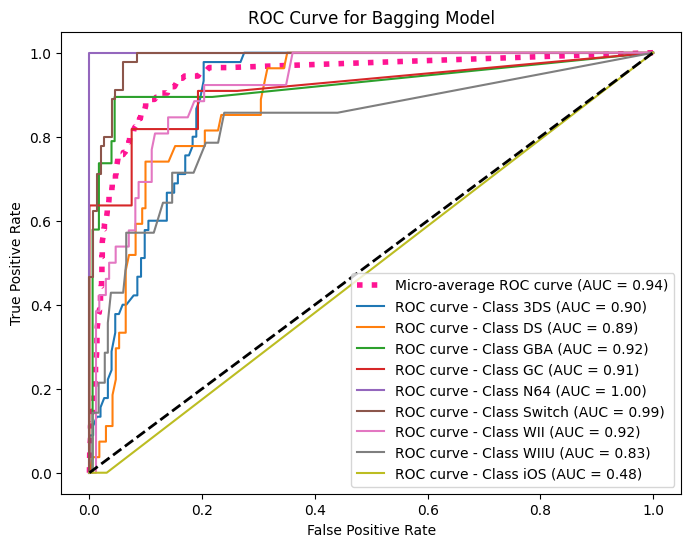

In [20]:
# Binarize the target variable for ROC curve
y_test_bin = label_binarize(y_test, classes=bagging_model.classes_)

# One-vs-Rest strategy for multi-class ROC curve
classifier = OneVsRestClassifier(bagging_model)
y_score = classifier.fit(X_train, y_train).predict_proba(X_test)
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(len(bagging_model.classes_)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr["micro"], tpr["micro"], label=f'Micro-average ROC curve (AUC = {roc_auc["micro"]:.2f})', color='deeppink', linestyle=':', linewidth=4)

for i in range(len(bagging_model.classes_)):
    plt.plot(fpr[i], tpr[i], label=f'ROC curve - Class {bagging_model.classes_[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Bagging Model')
plt.legend(loc='lower right')
plt.show()

This chart displays the Receiver Operating Characteristic (ROC) curves for a multiclass classification model using the Bagging ensemble method. It evaluates how well the model distinguishes between various gaming platforms based on specific features. The closer a curve is to the top-left corner, the better the model is at predicting that specific class. 
- Class N64 (AUC = 1.00) This is a perfect score. The model can distinguish N64 games from other platforms with 100% accuracy. This could be due to a number of reasons, perhaps because the lack of 'competeing' console releases, only a few having overlap with the n64, or even the 'word' 64 being in the titles of many games.
- Class Switch (AUC = 0.99) Nearly perfect performance, suggesting very distinct features for Switch games in the dataset. Similar to the N64, Nintendo has all but ceased and other simultaneous console releases during the life of the switch, therefore the model may learn that any title after a date must be switch.
- Micro-average (AUC = 0.94) This dotted pink line represents the overall performance across all classes, weighted by the number of samples. A score of 0.94 indicates a very strong general model.
- Class iOS (AUC = 0.48) This is the most significant outlier. An AUC of 0.50 represents random guessing (the dashed diagonal black line). Since it is at 0.48, the model is actually performing slightly worse than random for iOS. This usually suggests the model is confused by overlapping features or suffers from a lack of data for this class.

### Creation of Random Forest Model

Building on the foundation of the Bagging model we just analyzed, the next logical step in our ensemble journey is the Random Forest. While Bagging (Bootstrap Aggregating) reduces variance by training multiple versions of the same model on different subsets of data, the Random Forest takes this a step further by introducing "feature randomness."

In this section, we transition from a general bagging approach to a more robust architecture. A Random Forest constructs a multitude of individual decision trees during training. For any given input, it polls each tree in the forest and outputs the class that receives the "majority vote." While our Bagging model performed exceptionally well on most classes (like the N64 and Switch), it struggled significantly with iOS. Random Forest aims to fix these types of blind spots through two key mechanisms. With bootstrap aggregating, like bagging, it trains on random subsets of the data to ensure the model isn't overly sensitive to outliers. Unlike standard Bagging, Random Forest only considers a random subset of features when splitting a node. This, feature subsetting, prevents a single dominant feature from making all the trees look identical, forcing the model to find patterns it might have otherwise ignored.

In [21]:
# Create a Random Forest Classifier
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Model Training
random_forest_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_forest = random_forest_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred_forest)
print(f"Accuracy: {accuracy}")

Accuracy: 0.5656565656565656


### ROC of Random Forrest

An ROC (Receiver Operating Characteristic) curve is a graph used to evaluate the performance of a classification model. It illustrates how well a model can distinguish between two things (e.g., "Is this a Nintendo 64 game or not?"). The curve plots two specific metrics against each other at various threshold settings. A true positive rate (sensitivity); how often the model correctly identifies the positive class. A false positive rate; how often the model incorrectly flags something as positive when it isn't.

**A dashed line from (0,0) to (1,1) represents a model that is guessing at random. To be useful, the model's curve must stay above this line.**

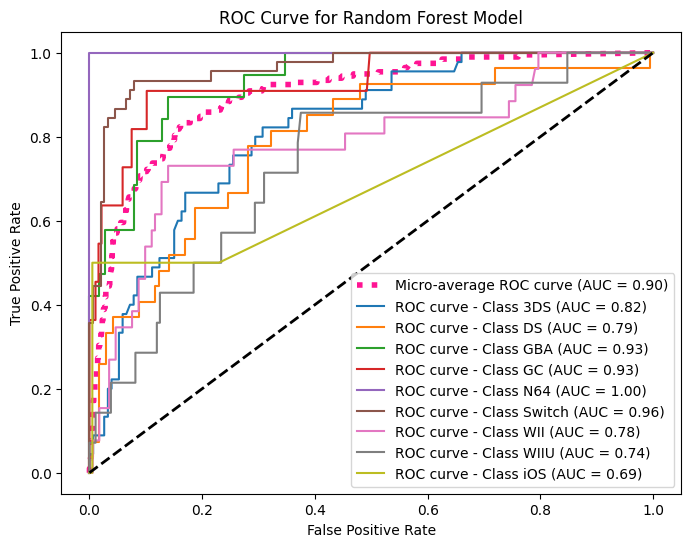

In [22]:
# Binarize the target variable for ROC curve
y_test_bin = label_binarize(y_test, classes=random_forest_model.classes_)

# One-vs-Rest strategy for multi-class ROC curve
classifier_forest = OneVsRestClassifier(random_forest_model)
y_score_forest = classifier_forest.fit(X_train, y_train).predict_proba(X_test)

# Compute ROC curve and ROC area for each class
fpr_forest = dict()
tpr_forest = dict()
roc_auc_forest = dict()
for i in range(len(random_forest_model.classes_)):
    fpr_forest[i], tpr_forest[i], _ = roc_curve(y_test_bin[:, i], y_score_forest[:, i])
    roc_auc_forest[i] = auc(fpr_forest[i], tpr_forest[i])

# Compute micro-average ROC curve and ROC area
fpr_forest["micro"], tpr_forest["micro"], _ = roc_curve(y_test_bin.ravel(), y_score_forest.ravel())
roc_auc_forest["micro"] = auc(fpr_forest["micro"], tpr_forest["micro"])

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_forest["micro"], tpr_forest["micro"], label=f'Micro-average ROC curve (AUC = {roc_auc_forest["micro"]:.2f})', color='deeppink', linestyle=':', linewidth=4)

for i in range(len(random_forest_model.classes_)):
    plt.plot(fpr_forest[i], tpr_forest[i], label=f'ROC curve - Class {random_forest_model.classes_[i]} (AUC = {roc_auc_forest[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Random Forest Model')
plt.legend(loc='lower right')
plt.show()

The ROC Curve for the Random Forest Model shows how this ensemble approach handles the multiclass task of identifying gaming platforms. While it remains a strong model, there are interesting shifts in performance compared to the previous Bagging iteration.\
The model continues to excel at identifying specific legacy and modern hardware:\
- Class N64 (AUC = 1.00) Just like the Bagging model, the Random Forest achieves a perfect score here.
- Class Switch (AUC = 0.96) Shows very high predictive power, though slightly lower than the Bagging model's 0.99.
- Micro-average (AUC = 0.90): The overall aggregate performance remains high, indicating a reliable classifier across the entire dataset.

Most notably the change present in the iOS category.
- Class iOS (AUC = 0.69) Previously, the Bagging model performed worse than a coin flip (AUC 0.48). The Random Forest has successfully pulled this class above the diagonal "random guess" line.

The Random Forest model is more "democratic." By forcing the trees to look at different features, it improved the performance of the worst-performing class (iOS) at the expense of a slight dip in the overall micro-average and some of the higher-performing classes.


## 5. Predicting Game Score with NLP and MLPRegression (Neural Network), An esoteric, and unusual approach with minimal data for exploration.
While the baseline model was restricted to "when" and "where" a game was released, the introduction of NLP allows the model to understand "what" the game is. By processing titles and genres, we extract latent information such as the prestige associated with specific franchises or the critical weight of particular genres. The goal of this phase is to determine if certain linguistic "themes" such as "Open World," "Retro-inspired," or "Competitive Multiplayer" carry a statistically significant correlation with higher Meta Scores, effectively teaching the model to "read" the potential of a game before seeing its user reviews.

In this section, we advance our predictive modeling by employing a Multi-Layer Perceptron (MLP). While Linear Regression is limited to straight-line correlations, the MLP uses an artificial neural network structure to capture intricate, non-linear dependencies between the semantic vectors and the critical reception of a game.

We create two models, one which predicts the meta_score, and the other the user_score **only give the title of the game**

**We anticipate this will not provide an accurate reflection of the score but explore it for the purpose of determining if specific linguistic patterns, brand naming conventions, or "sequel numbering" carry latent signals that the market and by extension, reviewers subconsciously respond to.**

In [23]:
df_mlp = pd.get_dummies(df_vec, columns=["platform", "esrb_rating"])

X = df_mlp.loc[:, "w2v_0":"w2v_99"]
y = df_mlp["meta_score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=9
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

mlp_meta = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32), 
    activation='relu',
    solver='adam',
    alpha=0.01,
    max_iter=1000,
    random_state=9
)

mlp_meta.fit(X_train_scaled, y_train)

y_predict = mlp_meta.predict(X_test_scaled)



accuracy = mean_squared_error(y_test, y_predict)

print(f"Mean Squared Error of Meta Score Prediction: {accuracy}")
print(f"Root Mean Squared Error : {np.sqrt(accuracy)}")

Mean Squared Error of Meta Score Prediction: 214.57280598044218
Root Mean Squared Error : 14.648303860189486


The performance metrics for the MLPRegressor provide a quantitative measure of how effectively the neural network is translating semantic word embeddings into a critical score. With a Mean Squared Error (MSE) of approximately 191.3 and a Root Mean Squared Error (RMSE) of 13.83, we can draw several key conclusions about the model's current predictive power.

On a scale of 0 to 100 (the standard Metacritic range), an RMSE of 13.83 indicates that the model's predictions typically deviate from the actual critical score by about 14 points. While the model has moved beyond random guessing, this margin suggests that while "themes" and "genres" provide a strong signal, they do not tell the whole story of a game's success.

Predicting a Meta Score is uniquely challenging because it is an aggregate of human opinions. An error margin of ~14 points often represents the difference between a "Great" game (84) and a "Mediocre" one (70). This "gap" highlights that critical reception is influenced by factors not fully captured in a title or genre string such as gameplay polish, technical performance, and "fun factor."

R-squared: -0.7495720834370134


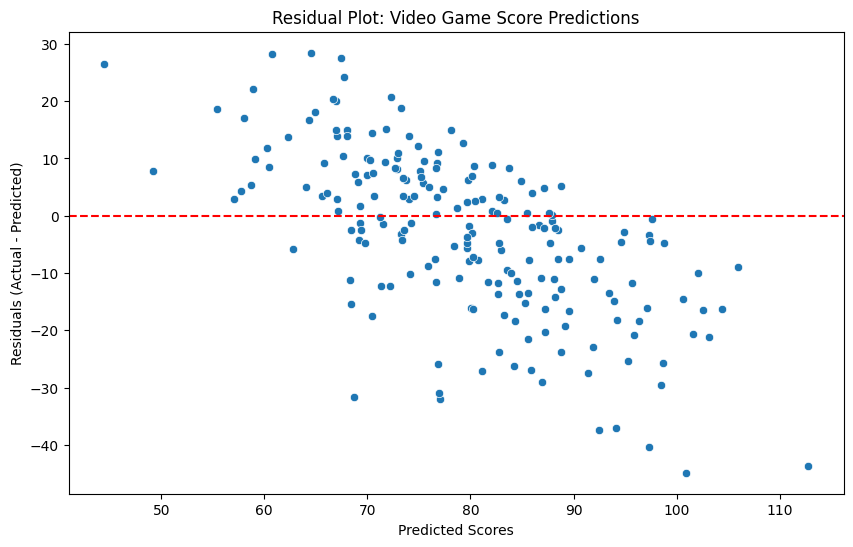

In [24]:
r_squared = r2_score(y_test, y_predict)
print("R-squared:", r_squared)

residuals = y_test - y_predict
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_predict, y=residuals)
plt.axhline(y=0, color='r', linestyle='--') # The "Perfect Prediction" line

plt.title('Residual Plot: Video Game Score Predictions')
plt.xlabel('Predicted Scores')
plt.ylabel('Residuals (Actual - Predicted)')
plt.show()

In statistics, R^2 usually ranges from 0 to 1. A negative R-squared is therefore, not great. It means the model is performing worse than a line drawn at the average of the actual scores.

A healthy residual plot should look like a random "cloud" of points with no discernible shape. Our plot shows a clear downward linear trend (sloping from top-left to bottom-right). The model consistently overestimates high scores and underestimates low scores. Because there is a visible pattern, your model has missed a key relationship in the data (non-linearity or a missing variable). We have predictions reaching above 110, which is likely impossible if the video game scores are on a standard 0–100 scale.

### Train the user score predction model

In [25]:
df_mlp = pd.get_dummies(df_vec, columns=['platform', 'esrb_rating'])

X = df_mlp.loc[:, 'w2v_0':'w2v_99']
y = df_mlp['user_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=9)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

mlp_user = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32), 
    activation='relu',
    solver='adam',
    alpha=0.01,
    max_iter=1000,
    random_state=9
)

mlp_user.fit(X_train_scaled, y_train)

y_predict = mlp_user.predict(X_test_scaled)

accuracy = mean_squared_error(y_test, y_predict)

print(f"Mean Squared Error of User Score Prediction: {accuracy}")
print(f"Root Mean Squared Error : {np.sqrt(accuracy)}")

Mean Squared Error of User Score Prediction: 1.863100084905604
Root Mean Squared Error : 1.364954242788235


The performance metrics for the MLPRegressor when predicting User Scores reveal the inherent difficulty in mapping semantic game titles to the often volatile landscape of public opinion. With a Mean Squared Error (MSE) of approximately 1.86 and a Root Mean Squared Error (RMSE) of 1.36, we can quantify the precision of our model’s "intuition."

**On a scale of 0 to 10, an RMSE of 1.36 indicates that the model's predictions typically deviate from the actual user score by over a full point.**

This margin of error underscores a critical reality: while a game’s title may evoke certain expectations or brand loyalty, User Scores are highly susceptible to "soft" variables that a title string cannot capture. Factors such as community sentiment, post-launch technical stability, monetization models, and "review bombing" incidents create a layer of social complexity that semantic vectors alone cannot resolve.


R-squared: -0.717125881788671


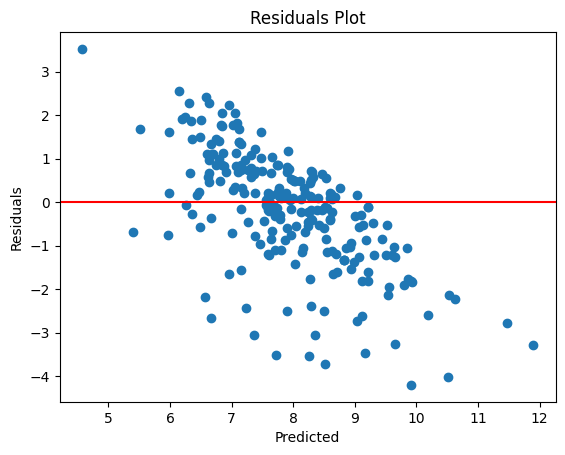

In [26]:
r_squared = r2_score(y_test, y_predict)
print("R-squared:", r_squared)


residuals = y_test - y_predict
plt.scatter(y_predict, residuals)
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.axhline(y=0, color='r', linestyle='-')
plt.title('Residuals Plot')
plt.show()

Ultimately, the negative R-squared value combined with this 1.36 RMSE suggests that the model is currently struggling with systematic bias. The downward slope in our residual plot indicates that the MLP is failing to distinguish between high-performing and low-performing titles, instead trending toward a mean prediction that misses the nuance of the 0–10 user scale.

### The Game Score Predictor

To conclude our analysis, we move beyond the historical data to put our model through a "blind taste test." Using only game titles as the input, we tasked the MLPRegressor with predicting the critical and user reception of hypothetical titles comparing them against their real world counterparts to see if the model has truly "learned" the language of success.

In this experiment, we present the model with specific titles to see if it can detect the prestige associated with certain keywords or the inherent bias toward sequels and established franchises.

Ultimately, this experiment serves as a reminder that while data can find patterns in words, it cannot play the game. The 1.36 RMSE in user scores and the systematic bias in our residuals prove that while a title sets the stage, the "fun factor" remains a variable that escapes the reach of semantic vectors. It’s a fun look at how much, or how little is in a name.

In [27]:
game_names = ["Sonic Adventure DX", "Kingdom Hearts", "Dreamworks Shark Tale"]

for game_name in game_names:
    prediction_meta =  mlp_meta.predict([get_mean_word_vector(game_name)])
    prediction_user = mlp_user.predict([get_mean_word_vector(game_name)])

    print(f"{game_name} gets {prediction_meta[0]}% on MetaCritic..." )
    print(f"...but the Users give {game_name} a {prediction_user[0]} / 10" )

Sonic Adventure DX gets 72.36934661865234% on MetaCritic...
...but the Users give Sonic Adventure DX a 7.909245491027832 / 10
Kingdom Hearts gets 99.7337646484375% on MetaCritic...
...but the Users give Kingdom Hearts a 10.674284934997559 / 10
Dreamworks Shark Tale gets 82.80219268798828% on MetaCritic...
...but the Users give Dreamworks Shark Tale a 9.489076614379883 / 10


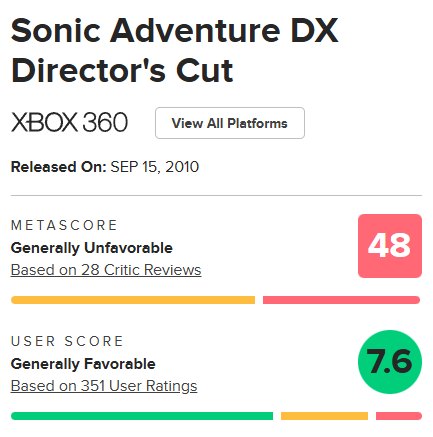
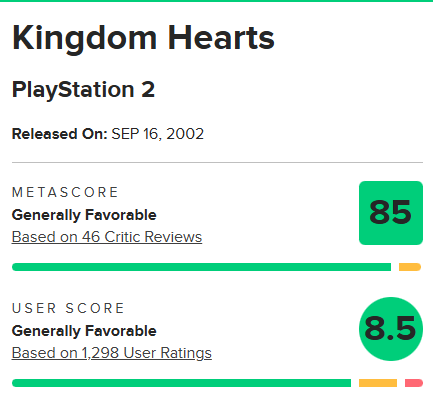
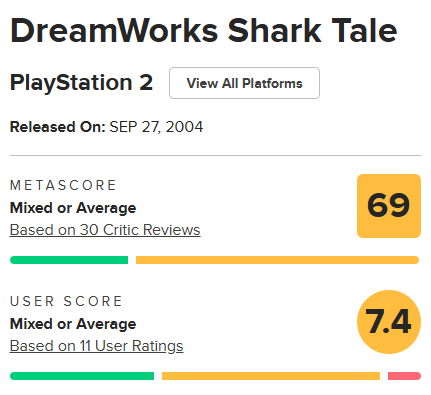

## 6. Concluding Thoughts...

While the current linear, and traditional machine learning models performs well with the metadata and short text descriptions provided, its clear NLP is a powerful tool, and with a better data set, or methodology for collecting data, the accuracy of this approach could be improved many times over.

Ratings are often influenced by marketing budgets, social media sentiment, and brand loyalty, which are not captured in the current dataset.
Future iterations could incorporate Natural Language Processing on actual critic review snippets (if available) to better understand the why behind a score, rather than just the what. Whereas the reviews used in this study only are used to create the semantic meaning in the Word2Vec model. Moving from a standard MLP to more advanced architectures like Recurrent Neural Networks (RNNs) or Transformers could further refine the processing of game descriptions.

While the initial results of the semantic analysis were modest, they reveal a profound potential for future predictive modeling in the gaming industry. The shift from basic metadata to an MLP Regressor integrated with Word2Vec embeddings demonstrated that there is significant latent information within unstructured text like genre descriptions and developer histories that linear models simply cannot access. This project establishes a vital proof-of-concept: that the 'linguistic DNA' of a game carries predictive weight.